## activation functions

In [ ]:
import numpy as np

def sigmoid(x):
    return 1/(1+np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0,x)

def leaky_relu(x):
    return np.where(x>0,x,0.01*x)

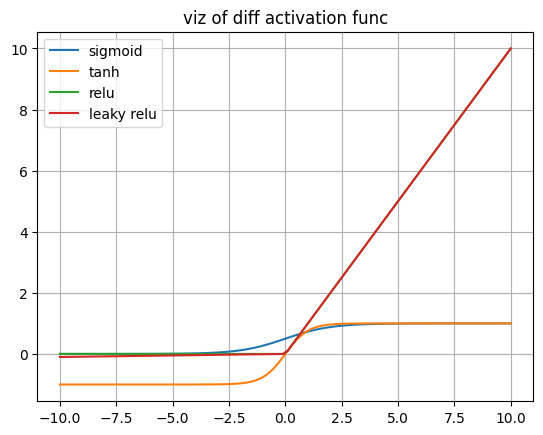

In [5]:
#viz of the actiavtion functions

import matplotlib.pyplot as plt
x=np.linspace(-10,10,100)
plt.plot(x,sigmoid(x), label="sigmoid")
plt.plot(x,tanh(x), label="tanh")
plt.plot(x,relu(x), label="relu")
plt.plot(x,leaky_relu(x), label="leaky relu")

plt.legend()
plt.title("viz of diff activation func")
plt.grid()
plt.show()

In [6]:
#deriv of the func

def sigmoid_deriv(x):
    s=sigmoid(x)
    return s*(1-s)

def tanh_deriv(x):
    return 1-np.tanh(x)**2

def relu_deriv(x):
    return np.where(x>0,1,0)

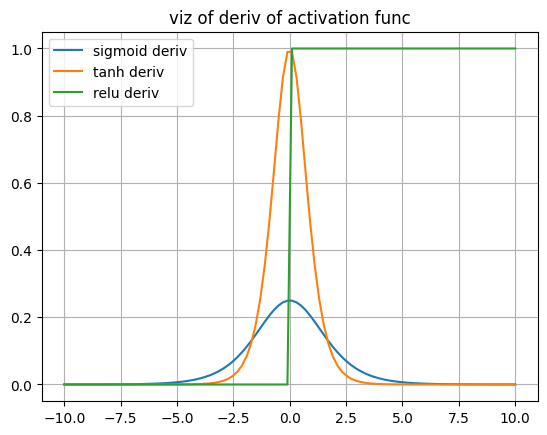

In [7]:
#viz for deriv

import matplotlib.pyplot as plt
x=np.linspace(-10,10,100)
plt.plot(x, sigmoid_deriv(x), label="sigmoid deriv")
plt.plot(x, tanh_deriv(x), label="tanh deriv")
plt.plot(x, relu_deriv(x), label="relu deriv")

plt.legend()
plt.title("viz of deriv of activation func")
plt.grid()
plt.show()

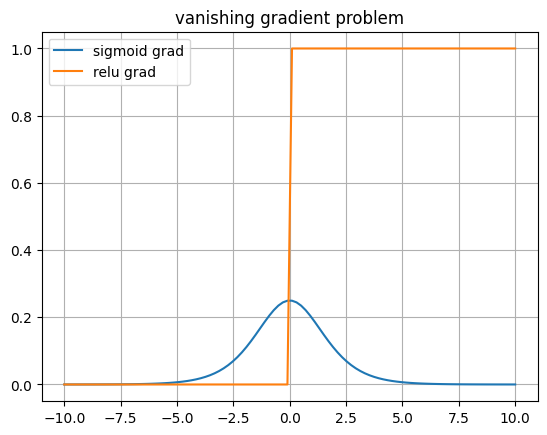

In [8]:
#to show vanishing gradient

import numpy as np
import matplotlib.pyplot as plt
x=np.linspace(-10,10,100)
s=sigmoid(x)
sig_grad=s*(1-s)
relu_grad=np.where(x>0,1,0)

plt.plot(x, sig_grad, label="sigmoid grad")
plt.plot(x, relu_grad, label="relu grad")

plt.legend()
plt.title("vanishing gradient problem")
plt.grid()
plt.show()

softmax output: [0.65900114 0.24243297 0.09856589]
sum: 1.0


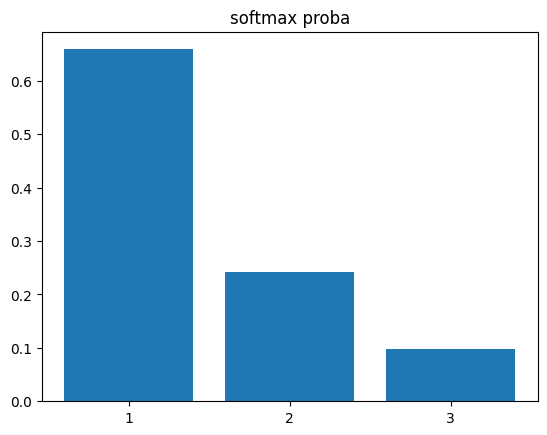

In [10]:
#softmax

import numpy as np
def soft(x):
    exp_x=np.exp(x-np.max(x))
    return exp_x/np.sum(exp_x)

#example
score=np.array([2,1,0.1])
prob=soft(score)
print("softmax output:",prob)
print("sum:",np.sum(prob))

#viz
import matplotlib.pyplot as plt
labels=['1','2','3']
plt.bar(labels,prob)
plt.title("softmax proba")
plt.show()

## and or xor using ANN

In [11]:
import numpy as np
X=np.array([[0,0],[0,1],[1,0],[1,1]])
y_and=np.array([[0],[0],[0],[1]])
y_or=np.array([[0],[1],[1],[1]])
y_xor=np.array([[0],[1],[1],[0]])

In [12]:
#model function

def train_nn(X,y,epochs=5000, lr=0.1):  #x is input, y is target
    np.random.seed(1)

    #Input (2) → Hidden (4) → Output (1)
    w1=np.random.randn(2,4)  #connects 2 i/p to 4 hidden
    b1=np.zeros((1,4))  #bias for w1
    w2=np.random.randn(4,1)  #connects 4 hidden to 1 o/p
    b2=np.zeros((1,1))  #o/p bias

    def sigm(x):
        return 1/(1+np.exp(-x))

    def sigm_deriv(x):
        return x*(1-x)

    for i in range(epochs):
        a1=sigm(np.dot(X,w1)+b1)  #fwd propagation -> z1=x*w1+b1, a1=sigm(z1)
        out=sigm(np.dot(a1,w2)+b2)  #o/p layer -> z2=a1*x+b2, out=sigm(z2)

        error=y-out
        d_out=error*sigm_deriv(out)  #grad loss -> del e= loss*gradient
        d_hidden=d_out.dot(w2.T)*sigm_deriv(a1)  #propagate it bwd

        w2+=a1.T.dot(d_out)*lr  #update the params
        b2+=np.sum(d_out, axis=0)
        w1+=X.T.dot(d_hidden)*lr
        b1+=np.sum(d_hidden, axis=0)

    return np.round(out)

In [14]:
#pred

print("and:\n",train_nn(X,y_and))
print("or:\n", train_nn(X,y_or))
print("xor:\n", train_nn(X,y_xor))

and:
 [[0.]
 [0.]
 [0.]
 [1.]]
or:
 [[0.]
 [1.]
 [1.]
 [1.]]
xor:
 [[0.]
 [1.]
 [1.]
 [0.]]


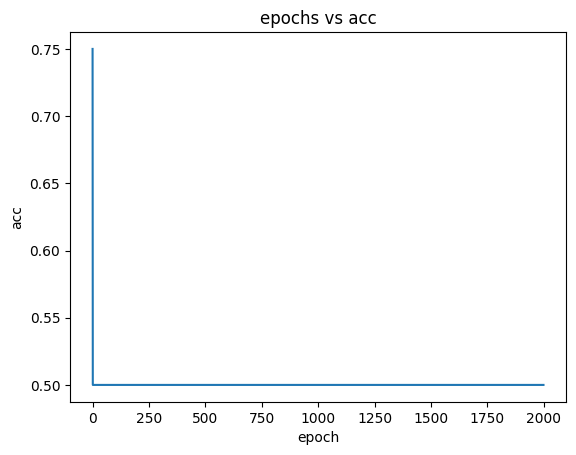

In [19]:
#compare epoch vs acc

import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

def sigm(x):
        return 1/(1+np.exp(-x))

def train_with_history(X,y,epochs=1000):
    np.random.seed(1)

    w1=np.random.randn(2,4)
    b1=np.zeros((1,4))
    w2=np.random.randn(4,1)
    b2=np.zeros((1,1))

    acc_list=[]

    for i in range(epochs):
        a1=sigm(np.dot(X,w1)+b1)
        out=sigm(np.dot(a1,w2)+b2)

        preds=np.round(out)
        acc=np.mean(preds==y)
        acc_list.append(acc)

        error=y-out;
        d_out=error*out*(1-out)
        d_hidden=d_out.dot(w2.T)*a1*(1-a1)

        w2+=a1.T.dot(d_out)*0.1
        w1=X.T.dot(d_hidden)*0.1

    return acc_list

import matplotlib.pyplot as plt
acc=train_with_history(X,y,epochs=2000)
plt.plot(acc)
plt.title("epochs vs acc")
plt.xlabel("epoch")
plt.ylabel("acc")
plt.show()

## ann on heart disease data

In [34]:
import pandas as pd
df=pd.read_csv("heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [35]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
cat_cols=df.select_dtypes(include=['object']).columns

for c in num_cols:
    df[c].fillna(df[c].mean(), inplace=True)

for c in cat_cols:
    df[c].fillna(df[c].mode()[0], inplace=True)

for c in ['id', 'dataset']:
    if c in df.columns:
        df.drop(c, axis=1, inplace=True)

if 'num' in df.columns:
    df['num']=df['num'].apply(lambda x:0 if x==0 else 1)

df.to_csv("cleaned_heart_disease_uci.csv",index=False)
df.head()

C:\Users\anjan\AppData\Local\Temp\ipykernel_12668\2574445990.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[c].fillna(df[c].mean(), inplace=True)
C:\Users\anjan\AppData\Local\Temp\ipykernel_12668\2574445990.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [36]:
#visualization

import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.corr(), annot=True)
plt.title("corr heatmap")
plt.show()

ValueError: could not convert string to float: 'Male'

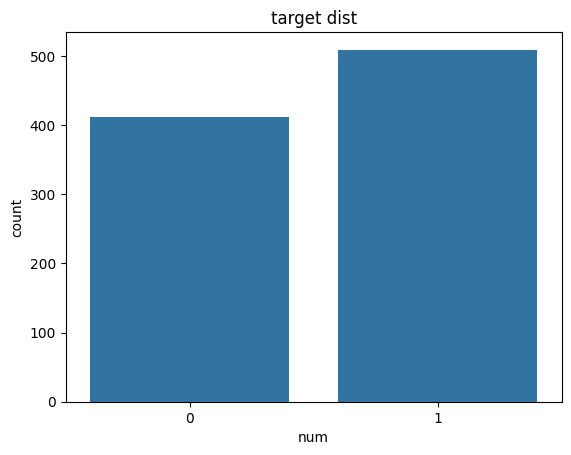

In [37]:
sns.countplot(x=df[df.columns[-1]])
plt.title("target dist")
plt.show()

In [40]:
#encode and split and scale

df=pd.get_dummies(df, drop_first=True)

from sklearn.model_selection import train_test_split
X=df.drop(df.columns[-1],axis=1)
y=df[df.columns[-1]]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
x_test=sc.transform(X_test)

In [45]:
#ann model defn

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
#Input → Hidden Layer (16 neurons) → Output Layer (1 neuron)
model=Sequential([
    Dense(16, activation='relu',input_shape=(X_train.shape[1],)),  #hidden -> fully connected, 16 neurons, relu, no.of features
    Dense(1,activation='sigmoid')  #output layer -> 1 neuron cuz binary
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
history=model.fit(
    X_train, y_train, epochs=30, batch_size=16, validation_split=0.2
)

Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5170 - loss: 0.7269 - val_accuracy: 0.6689 - val_loss: 0.6249
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7075 - loss: 0.5813 - val_accuracy: 0.7905 - val_loss: 0.5341
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7976 - loss: 0.4925 - val_accuracy: 0.8176 - val_loss: 0.4684
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8435 - loss: 0.4314 - val_accuracy: 0.8649 - val_loss: 0.4209
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8690 - loss: 0.3842 - val_accuracy: 0.8851 - val_loss: 0.3791
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8878 - loss: 0.3464 - val_accuracy: 0.8784 - val_loss: 0.3426
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9031 - loss: 0.3118 - val_accuracy: 0.8851 - val_loss: 0.3124
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9133 - loss: 0.2825 - val_accuracy: 0.8986 - val_loss

In [47]:
#evaluation

loss,acc=model.evaluate(X_test,y_test)
print("test acc", acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7989 - loss: 24.5194
test acc 0.7989130616188049


In [48]:
#pred

y_pred=(model.predict(X_test)>0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [49]:
from sklearn.metrics import confusion_matrix, classification_report

print("confu matrix:")
print(confusion_matrix(y_test,y_pred))
print("classif report")
print(classification_report(y_test,y_pred))

confu matrix:
[[147   0]
 [ 37   0]]
classif report
              precision    recall  f1-score   support

       False       0.80      1.00      0.89       147
        True       0.00      0.00      0.00        37

    accuracy                           0.80       184
   macro avg       0.40      0.50      0.44       184
weighted avg       0.64      0.80      0.71       184



C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

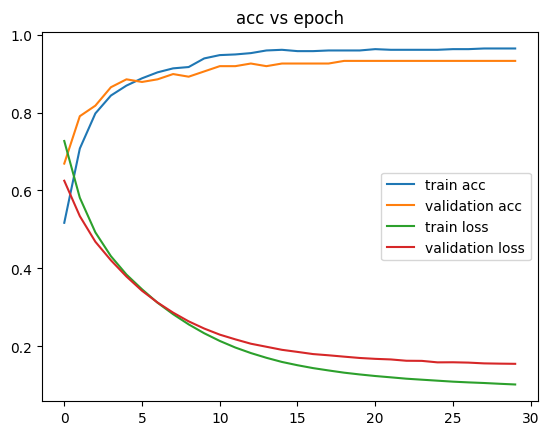

In [52]:
# visualizations

import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label="train acc")
plt.plot(history.history['val_accuracy'], label="validation acc")
plt.plot(history.history['loss'], label="train loss")
plt.plot(history.history['val_loss'], label="validation loss")

plt.legend()
plt.title("acc vs epoch")
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


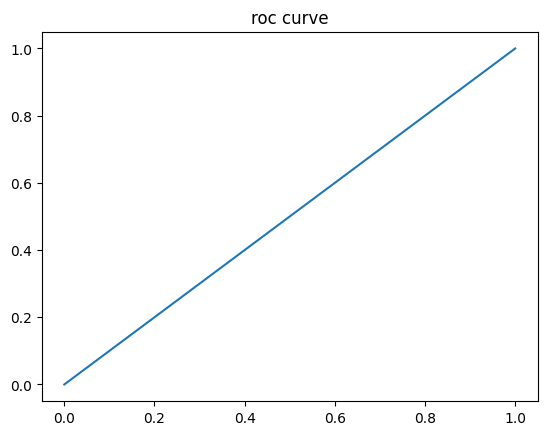

In [53]:
#roc curve

from sklearn.metrics import roc_curve
y_prob=model.predict(X_test)
fpr,tpr,_=roc_curve(y_test,y_pred)
plt.plot(fpr,tpr)
plt.title("roc curve")
plt.show()